## Anomaly Detection System Notebook

This notebook walks through the process of loading, preprocessing, and analyzing time-series sensor data for anomaly detection using an autoencoder neural network.

Let's start by importing the necessary libraries and loading the dataset.

In [6]:
import os
import pandas as pd
import numpy as np


In [7]:
# Load the data
file_path = r'path\data.csv'
data = pd.read_csv(file_path, parse_dates=True, index_col=0)

In [8]:
data

,OPZ_IMX.IMX001.P-2A.TT-111_P-2A,OPZ_IMX.IMX001.P-2A.VT-111_P-2A,OPZ_IMX.IMX002.P-2A.PT-111_P-2A,OPZ_PCS.PLC000.P-2A.PIT_P2A
_time,,,,
2023-05-24 09:07:20+00:00,NaN,NaN,NaN,1.205732
2023-05-24 09:07:54+00:00,NaN,NaN,NaN,1.203171
2023-05-24 09:07:59+00:00,NaN,NaN,NaN,1.207269
2023-05-24 09:08:10+00:00,NaN,NaN,NaN,1.210497
2023-05-24 09:08:19+00:00,NaN,NaN,NaN,1.206266
...,...,...,...,...
2023-07-18 00:49:23.864000+00:00,NaN,NaN,4.166207,NaN
2023-07-18 00:49:24.020000+00:00,NaN,NaN,NaN,1.243989
2023-07-18 00:49:24.811000+00:00,NaN,7.486464,NaN,NaN


In [9]:
# Summary statistics of the dataset
summary_stats = data.describe(include='all')

# Count of missing values in each column
missing_values_count = data.isnull().sum()

# Concatenate summary statistics and missing values count
summary_and_missing_values = pd.concat([summary_stats.transpose(), missing_values_count], axis=1)
summary_and_missing_values.columns = list(summary_and_missing_values.columns[:-1]) + ['missing_values_count']

summary_and_missing_values


,count,mean,std,min,25%,50%,75%,max,missing_values_count
OPZ_IMX.IMX001.P-2A.TT-111_P-2A,1654760.0,32.373839,3.028378,22.900413,30.388865,32.601799,34.476322,39.927067,5466717
OPZ_IMX.IMX001.P-2A.VT-111_P-2A,2553243.0,1.441485,0.845420,0.004711,1.046404,1.223868,1.738622,10.215902,4568234
OPZ_IMX.IMX002.P-2A.PT-111_P-2A,2555480.0,3.215694,0.678223,-0.103997,3.133183,3.358910,3.558534,7.317659,4565997
OPZ_PCS.PLC000.P-2A.PIT_P2A,2621597.0,1.230441,0.192027,-0.089900,1.151219,1.242007,1.322594,3.688809,4499880


In [10]:
# Handle missing values using a combination of forward fill and backward fill
data_filled = data.ffill().bfill()

# Check if there are any remaining missing values
remaining_missing_values = data_filled.isnull().sum().sum()
remaining_missing_values

0

# Model Training

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Normalize the data
scaler = StandardScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data_filled), columns=data_filled.columns, index=data_filled.index)

# Split the data into training and validation sets (80% training, 20% validation)
train_data, val_data = train_test_split(data_scaled, test_size=0.2, shuffle=False)

# Display the shape of the training and validation sets
train_data.shape, val_data.shape


((5697181, 4), (1424296, 4))

In [12]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Define the architecture of the autoencoder
input_dim = train_data.shape[1]
encoding_dim = int(input_dim / 2)

# Encoder with L1 regularization
input_layer = Input(shape=(input_dim,))
encoder = Dense(encoding_dim, activation='relu', activity_regularizer=regularizers.l1(10e-5))(input_layer)

# Decoder with L1 regularization
decoder = Dense(input_dim, activation='linear', activity_regularizer=regularizers.l1(10e-5))(encoder)

# Autoencoder
autoencoder = Model(inputs=input_layer, outputs=decoder)

# Compile the model
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Define Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the autoencoder with Early Stopping
history = autoencoder.fit(train_data, train_data,
                          epochs=3,
                          batch_size=256,
                          shuffle=True,
                          validation_data=(val_data, val_data),
                          callbacks=[early_stopping],
                          verbose=1)

# Extract the encoder model
encoder_model = Model(inputs=input_layer, outputs=encoder)


Epoch 1/3
22255/22255 [==============================] - 21s 913us/step - loss: 0.2151 - val_loss: 1.5883
Epoch 2/3
22255/22255 [==============================] - 21s 959us/step - loss: 0.1777 - val_loss: 1.5884
Epoch 3/3
22255/22255 [==============================] - 20s 899us/step - loss: 0.1776 - val_loss: 1.6006


# 1. Evaluate Reconstruction Error:

In [13]:
# Calculate the reconstruction error on the validation set
reconstructed_data = autoencoder.predict(val_data)
reconstruction_error = np.mean(np.power(val_data - reconstructed_data, 2), axis=1)


44510/44510 [==============================] - 27s 614us/step


# 2. Determine Threshold for Anomalies:

In [14]:
# Determine the threshold for anomalies
threshold = np.percentile(reconstruction_error, 99)  # 99th percentile

# 3. Identify Anomalies:

In [15]:
# Identify anomalies in the validation set
anomalies = val_data[reconstruction_error > threshold]

In [16]:
anomalies

,OPZ_IMX.IMX001.P-2A.TT-111_P-2A,OPZ_IMX.IMX001.P-2A.VT-111_P-2A,OPZ_IMX.IMX002.P-2A.PT-111_P-2A,OPZ_PCS.PLC000.P-2A.PIT_P2A
_time,,,,
2023-07-12 09:48:53.954000+00:00,-0.363005,3.431855,-3.134002,-0.221899
2023-07-12 09:48:53.986000+00:00,-0.363005,3.431855,-3.130905,-0.221899
2023-07-12 09:48:54.474000+00:00,-0.363005,3.431855,-3.130905,-0.216818
2023-07-12 10:46:49.603000+00:00,-0.275237,4.965201,-0.733017,-0.668370
2023-07-12 10:46:49.649000+00:00,-0.275237,4.965201,-0.676960,-0.752882
...,...,...,...,...
2023-07-18 00:49:23.864000+00:00,0.364442,4.739510,1.421595,0.147985
2023-07-18 00:49:24.020000+00:00,0.364442,4.739510,1.421595,0.065875
2023-07-18 00:49:24.811000+00:00,0.364442,6.835876,1.421595,0.065875


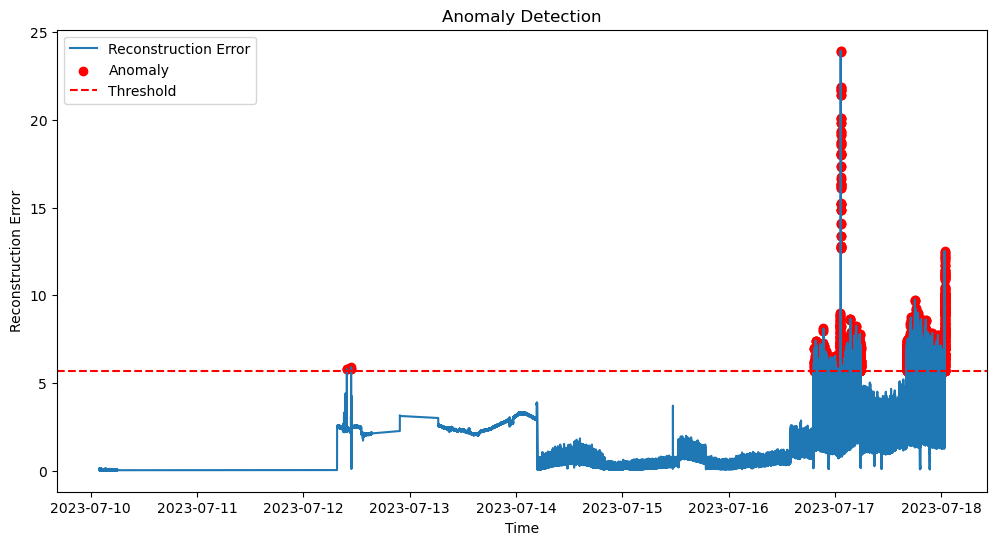

In [17]:
import matplotlib.pyplot as plt

# Create a DataFrame with reconstruction error and a column indicating anomalies
error_df = pd.DataFrame({'reconstruction_error': reconstruction_error, 'anomaly': reconstruction_error > threshold})
error_df.index = val_data.index

# Plot the original time series data and highlight anomalies
plt.figure(figsize=(12, 6))

# Plot reconstruction error
plt.plot(error_df.index, error_df['reconstruction_error'], label='Reconstruction Error')

# Highlight anomalies
plt.scatter(error_df.index[error_df['anomaly']], error_df['reconstruction_error'][error_df['anomaly']], color='r', label='Anomaly')

# Add threshold line
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Add labels and legend
plt.title('Anomaly Detection')
plt.xlabel('Time')
plt.ylabel('Reconstruction Error')
plt.legend()

plt.show()


In [18]:
# Get the indices of the anomalies in the original dataset
anomaly_indices = anomalies.index

# Extract the corresponding real values from the original dataset
real_values_anomalies = data_filled.loc[anomaly_indices]


In [19]:
data_filled.describe()

,OPZ_IMX.IMX001.P-2A.TT-111_P-2A,OPZ_IMX.IMX001.P-2A.VT-111_P-2A,OPZ_IMX.IMX002.P-2A.PT-111_P-2A,OPZ_PCS.PLC000.P-2A.PIT_P2A
count,7.121477e+06,7.121477e+06,7.121477e+06,7.121477e+06
mean,3.275667e+01,1.507086e+00,3.255226e+00,1.232936e+00
std,3.190230e+00,8.747056e-01,6.408162e-01,1.677785e-01
min,2.290041e+01,4.711246e-03,-1.039972e-01,-8.990031e-02
25%,3.068573e+01,1.058084e+00,3.167307e+00,1.145649e+00
50%,3.287458e+01,1.240831e+00,3.381955e+00,1.244880e+00
75%,3.501646e+01,1.869240e+00,3.571063e+00,1.325478e+00
max,3.992707e+01,1.021590e+01,7.317659e+00,3.688809e+00


# 4. Analyzing each sensor

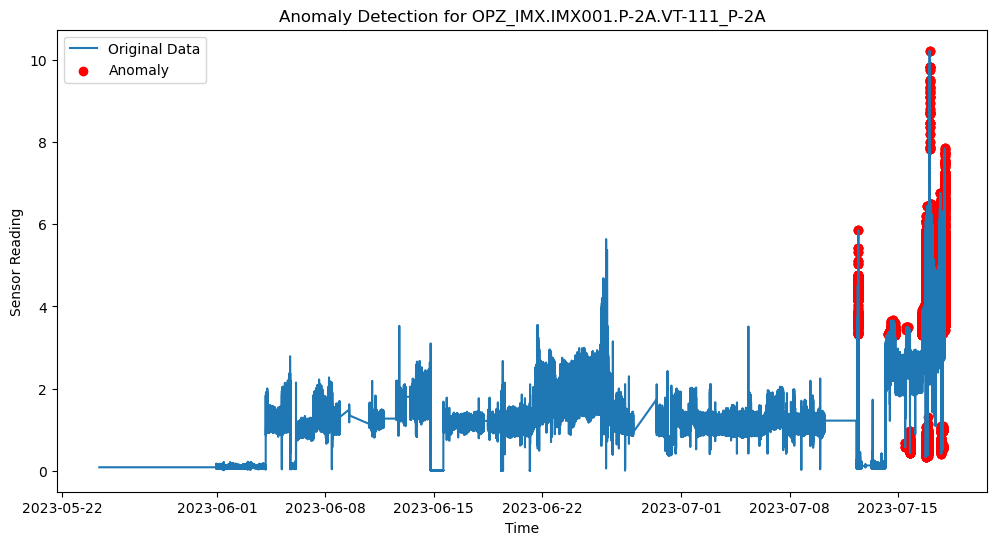

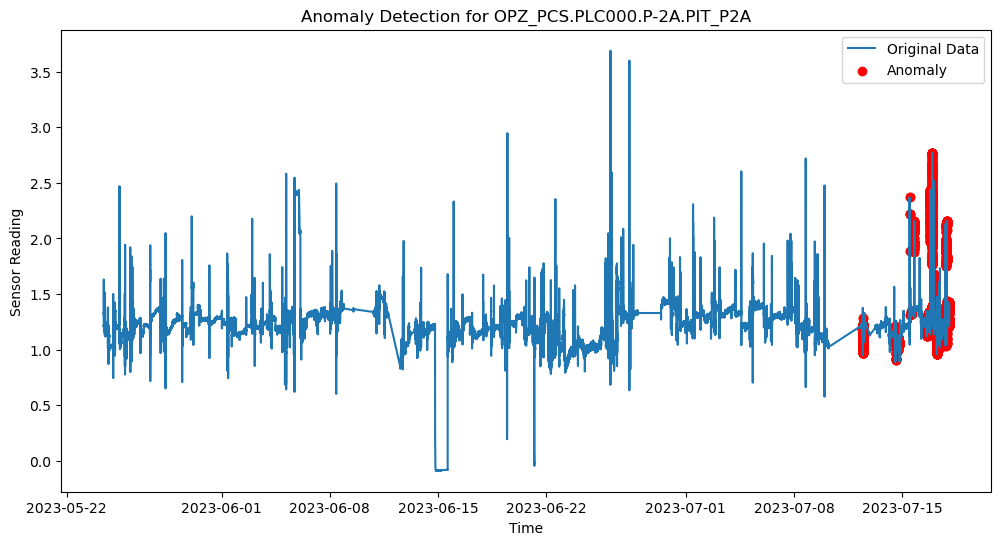

In [66]:
# Calculate the squared difference for each sensor
squared_difference = np.power(val_data - reconstructed_data, 2)

# For each anomaly, determine which sensor has the highest squared difference
anomalies_sensor_contribution = squared_difference.loc[anomalies.index].idxmax(axis=1)

# Get a count of how many times each sensor was the main contributor
sensor_counts = anomalies_sensor_contribution.value_counts()

# Select the top two sensors
top_two_sensors = sensor_counts.head(2).index

# For each of the top two sensors, plot the original time series data and overlay the anomalous points
for sensor in top_two_sensors:
    real_values_anomalies = data_filled.loc[anomalies.index, sensor]
    
    plt.figure(figsize=(12, 6))
    
    # Plot the original time series data
    plt.plot(data_filled.index, data_filled[sensor], label='Original Data')
    
    # Overlay the anomalous points
    plt.scatter(real_values_anomalies.index, real_values_anomalies, color='r', label='Anomaly')
    
    # Add labels and legend
    plt.title(f'Anomaly Detection for {sensor}')
    plt.xlabel('Time')
    plt.ylabel('Sensor Reading')
    plt.legend()
    
    plt.show()


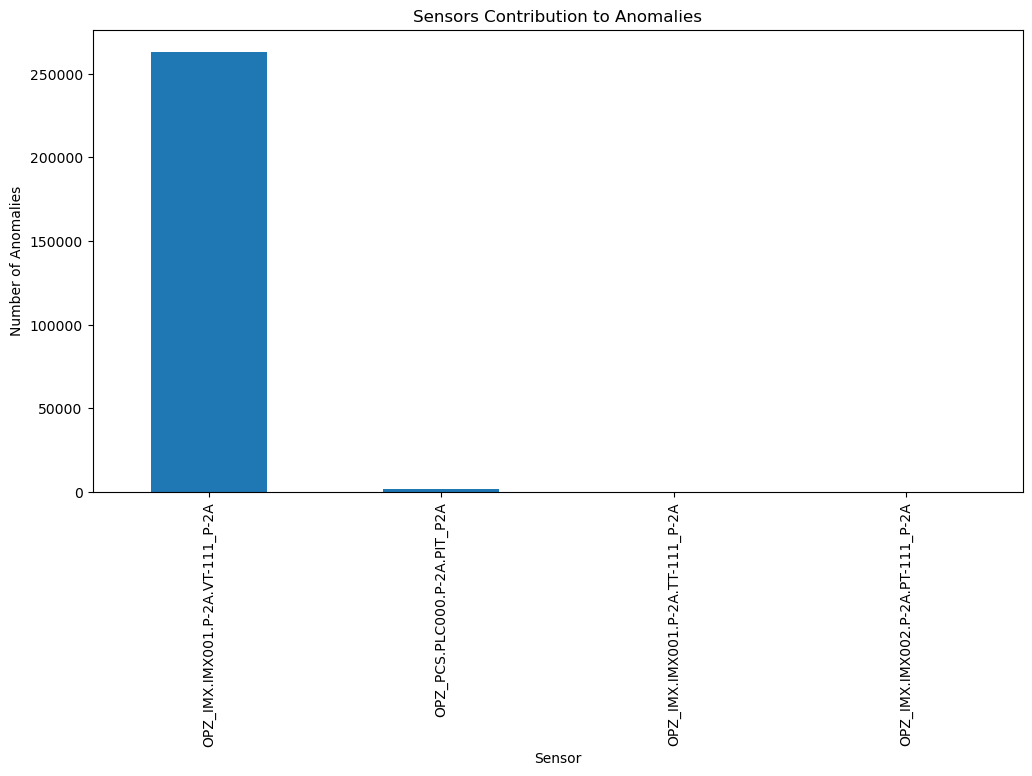

In [67]:
anomalies_sensor_contribution.value_counts().plot(kind='bar', figsize=(12, 6))
plt.title('Sensors Contribution to Anomalies')
plt.xlabel('Sensor')
plt.ylabel('Number of Anomalies')
plt.show()


# 5. Saving the TensorFlow model

In [71]:
autoencoder.save('path_to_saved_model')

INFO:tensorflow:Assets written to: path_to_saved_model\assets


INFO:tensorflow:Assets written to: path_to_saved_model\assets


In [78]:
from tensorflow.keras.utils import plot_model
plot_model(autoencoder, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)


You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.
